# E-Commerce Sales Analysis
## Exploratory Data Analysis — Olist Brazilian E-Commerce Dataset

**Author:** Andre Musari  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Dataset Size:** 100,000+ orders | 2016–2018  

---

### Analysis Objectives
1. Understand overall sales trends over time
2. Identify top-performing product categories
3. Analyze customer geographic distribution
4. Evaluate delivery performance and customer satisfaction
5. Surface business insights from transactional data

In [6]:
!pip install opendatasets -q
import opendatasets as od
od.download("https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: andremusari
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:00<00:00, 163MB/s]


In [2]:
import os

# Cek isi folder dataset
files = os.listdir('./brazilian-ecommerce')
for f in sorted(files):
    print(f)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [7]:
import os
os.chdir('./brazilian-ecommerce')

orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
products  = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
category  = pd.read_csv('product_category_name_translation.csv')

print(f'Orders    : {orders.shape[0]:,} rows')
print(f'Items     : {items.shape[0]:,} rows')
print(f'Products  : {products.shape[0]:,} rows')
print(f'Customers : {customers.shape[0]:,} rows')
print(f'Reviews   : {reviews.shape[0]:,} rows')

Orders    : 99,441 rows
Items     : 112,650 rows
Products  : 32,951 rows
Customers : 99,441 rows
Reviews   : 99,224 rows


---
## 1. Environment Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor'  : '#0f0f0f',
    'axes.facecolor'    : '#0f0f0f',
    'axes.edgecolor'    : '#2a2a2a',
    'axes.labelcolor'   : '#cccccc',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : '#ffffff',
    'axes.grid'         : True,
    'grid.color'        : '#1e1e1e',
    'grid.linewidth'    : 0.6,
    'xtick.color'       : '#888888',
    'ytick.color'       : '#888888',
    'text.color'        : '#cccccc',
    'font.family'       : 'monospace',
    'figure.dpi'        : 120
})

ACCENT  = '#00d4ff'
ACCENT2 = '#ff6b35'
PALETTE = ['#00d4ff','#ff6b35','#7fff6b','#ffcc00','#cc44ff','#ff4488']

print('Environment ready.')

Environment ready.


---
## 2. Download Dataset

Run the cell below to download the Olist dataset directly into Colab.

In [8]:
import subprocess
subprocess.run(['pip', 'install', 'kaggle', '-q'])

# If you have kaggle.json API key, upload it and run:
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d olistbr/brazilian-ecommerce --unzip

# Alternative: download via gdown (public mirror)
import os
print('Please upload your dataset CSV files to this Colab session.')
print('Or use: kaggle datasets download -d olistbr/brazilian-ecommerce --unzip')

Please upload your dataset CSV files to this Colab session.
Or use: kaggle datasets download -d olistbr/brazilian-ecommerce --unzip


---
## 3. Data Loading

In [9]:
orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
products  = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
category  = pd.read_csv('product_category_name_translation.csv')

print(f'Orders    : {orders.shape[0]:,} rows')
print(f'Items     : {items.shape[0]:,} rows')
print(f'Products  : {products.shape[0]:,} rows')
print(f'Customers : {customers.shape[0]:,} rows')
print(f'Reviews   : {reviews.shape[0]:,} rows')

Orders    : 99,441 rows
Items     : 112,650 rows
Products  : 32,951 rows
Customers : 99,441 rows
Reviews   : 99,224 rows


---
## 4. Data Cleaning

In [10]:
print('=== Missing Values per Table ===')
for name, df_temp in [('orders', orders), ('items', items),
                      ('products', products), ('customers', customers),
                      ('reviews', reviews)]:
    missing = df_temp.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'\n[{name}]')
        print(missing.to_string())
    else:
        print(f'\n[{name}] — no missing values')

=== Missing Values per Table ===

[orders]
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

[items] — no missing values

[products]
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2

[customers] — no missing values

[reviews]
review_comment_title      87656
review_comment_message    58247


In [11]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders_clean = orders[orders['order_status'] == 'delivered'].copy()
orders_clean.dropna(subset=['order_delivered_customer_date'], inplace=True)

print(f'Delivered orders : {len(orders_clean):,}')
print(f'Dropped          : {len(orders) - len(orders_clean):,}')

Delivered orders : 96,470
Dropped          : 2,971


In [12]:
df = (
    orders_clean
    .merge(items,     on='order_id',   how='left')
    .merge(products,  on='product_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(category,  on='product_category_name', how='left')
)

df['year']          = df['order_purchase_timestamp'].dt.year
df['month']         = df['order_purchase_timestamp'].dt.month
df['day_of_week']   = df['order_purchase_timestamp'].dt.day_name()
df['hour']          = df['order_purchase_timestamp'].dt.hour
df['year_month']    = df['order_purchase_timestamp'].dt.to_period('M')
df['revenue']       = df['price'] + df['freight_value']
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days
df['delivered_on_time'] = (
    df['order_delivered_customer_date'] <= df['order_estimated_delivery_date']
)

print(f'Master dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Master dataframe: 110,189 rows x 35 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_category_name_english,year,month,day_of_week,hour,year_month,revenue,delivery_days,delivered_on_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,SP,housewares,2017,10,Monday,10,2017-10,38.71,8,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,BA,perfumery,2018,7,Tuesday,20,2018-07,141.46,13,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,GO,auto,2018,8,Wednesday,8,2018-08,179.12,9,True


---
## 5. Exploratory Data Analysis

### 5.1 Monthly Revenue Trend

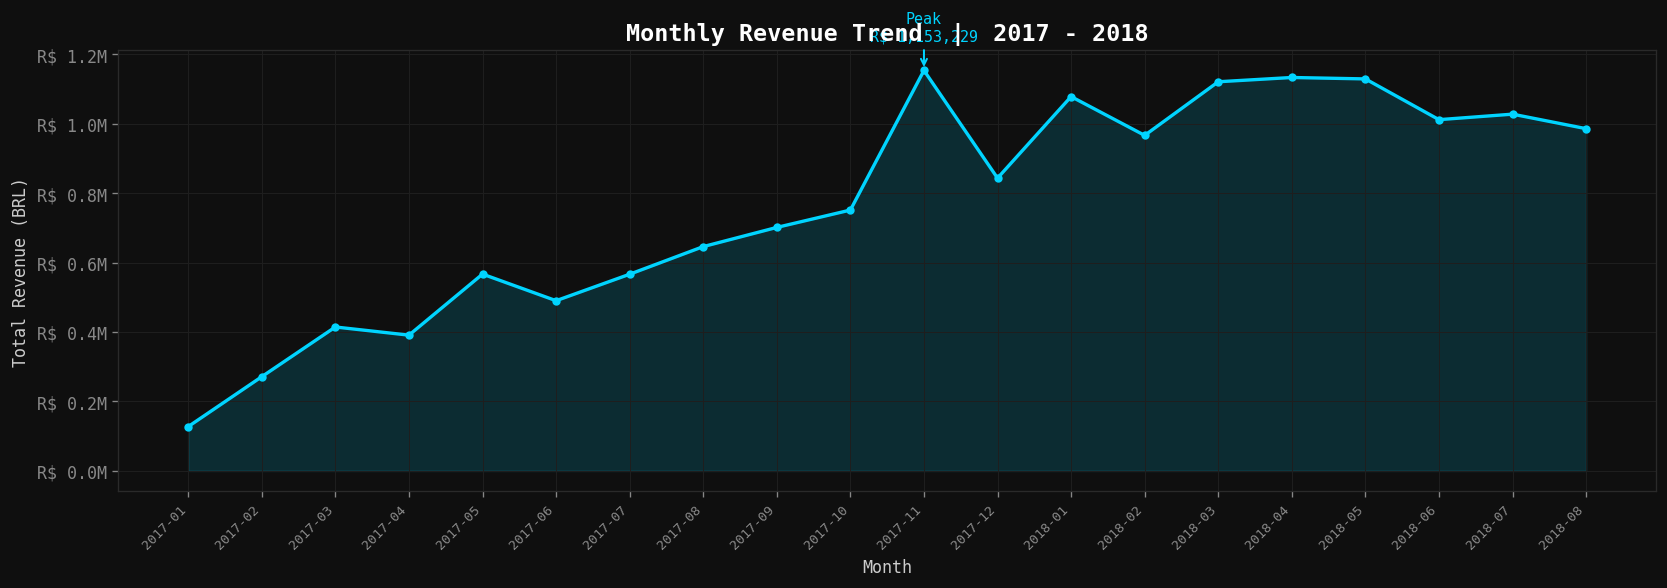

In [13]:
monthly = (
    df.groupby('year_month')['revenue']
    .sum()
    .reset_index()
)
monthly['year_month_str'] = monthly['year_month'].astype(str)
monthly = monthly[monthly['year_month_str'] >= '2017-01']

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly['year_month_str'], monthly['revenue'],
                alpha=0.15, color=ACCENT)
ax.plot(monthly['year_month_str'], monthly['revenue'],
        color=ACCENT, linewidth=2, marker='o', markersize=4)

peak_idx = monthly['revenue'].idxmax()
ax.annotate(
    f"Peak\nR$ {monthly.loc[peak_idx,'revenue']:,.0f}",
    xy=(monthly.loc[peak_idx,'year_month_str'], monthly.loc[peak_idx,'revenue']),
    xytext=(0, 18), textcoords='offset points',
    ha='center', fontsize=9, color=ACCENT,
    arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.2)
)

ax.set_title('Monthly Revenue Trend  |  2017 - 2018')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_xticklabels(monthly['year_month_str'], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Top 10 Product Categories by Revenue

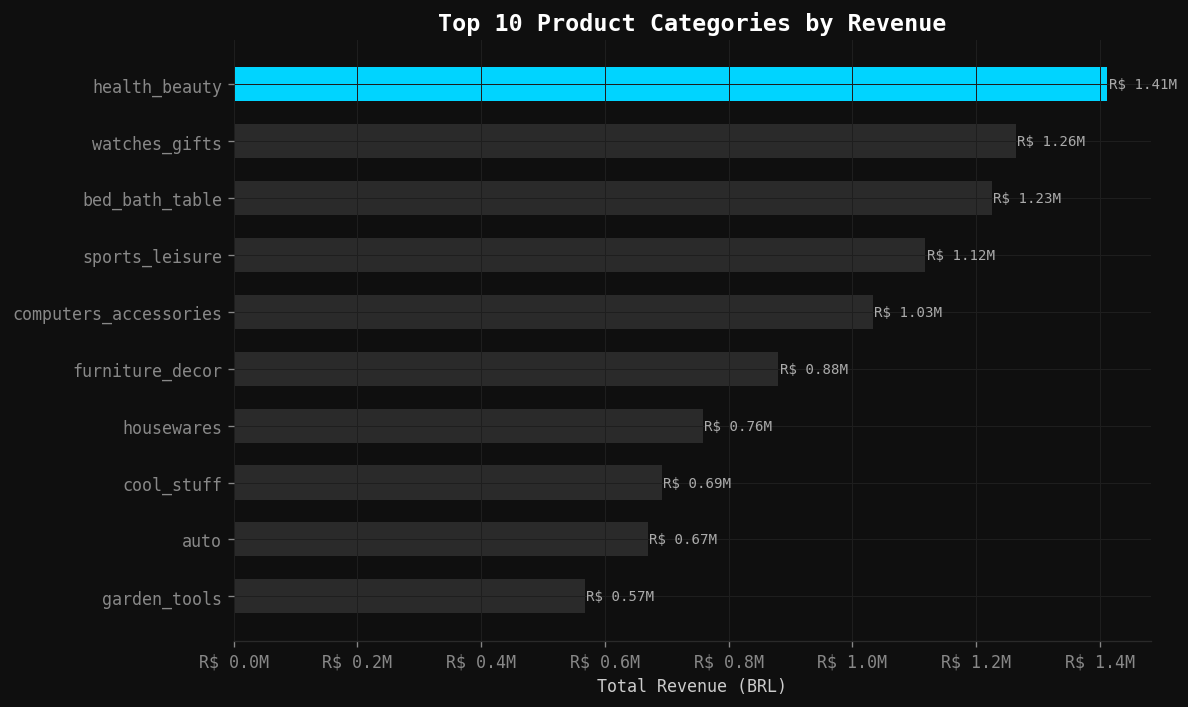

In [14]:
cat_rev = (
    df.groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

colors = [ACCENT if i == len(cat_rev)-1 else '#2a2a2a' for i in range(len(cat_rev))]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_rev.index, cat_rev.values, color=colors, height=0.6)

for bar, val in zip(bars, cat_rev.values):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'R$ {val/1e6:.2f}M', va='center', fontsize=8.5, color='#aaaaaa')

ax.set_title('Top 10 Product Categories by Revenue')
ax.set_xlabel('Total Revenue (BRL)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Order Volume Heatmap

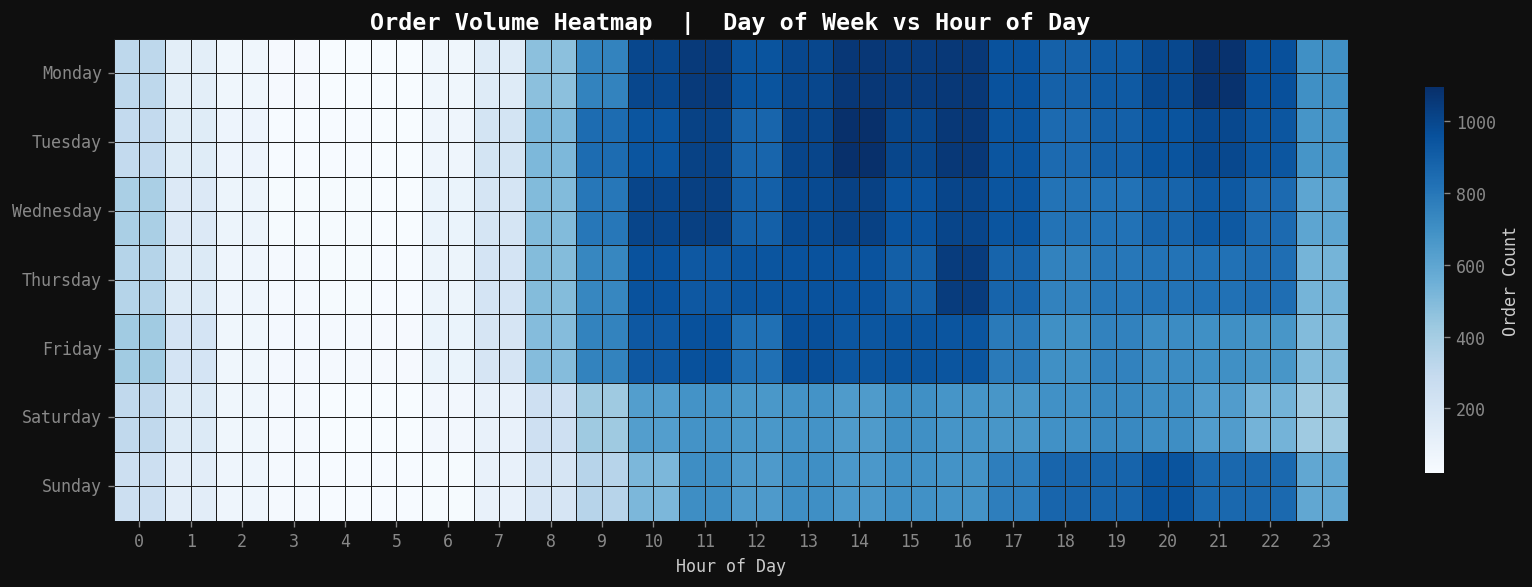

In [15]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = (
    df.groupby(['day_of_week','hour'])['order_id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data, ax=ax,
    cmap='Blues', linewidths=0.3, linecolor='#1a1a1a',
    cbar_kws={'label': 'Order Count', 'shrink': 0.8}
)
ax.set_title('Order Volume Heatmap  |  Day of Week vs Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('order_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Delivery Performance

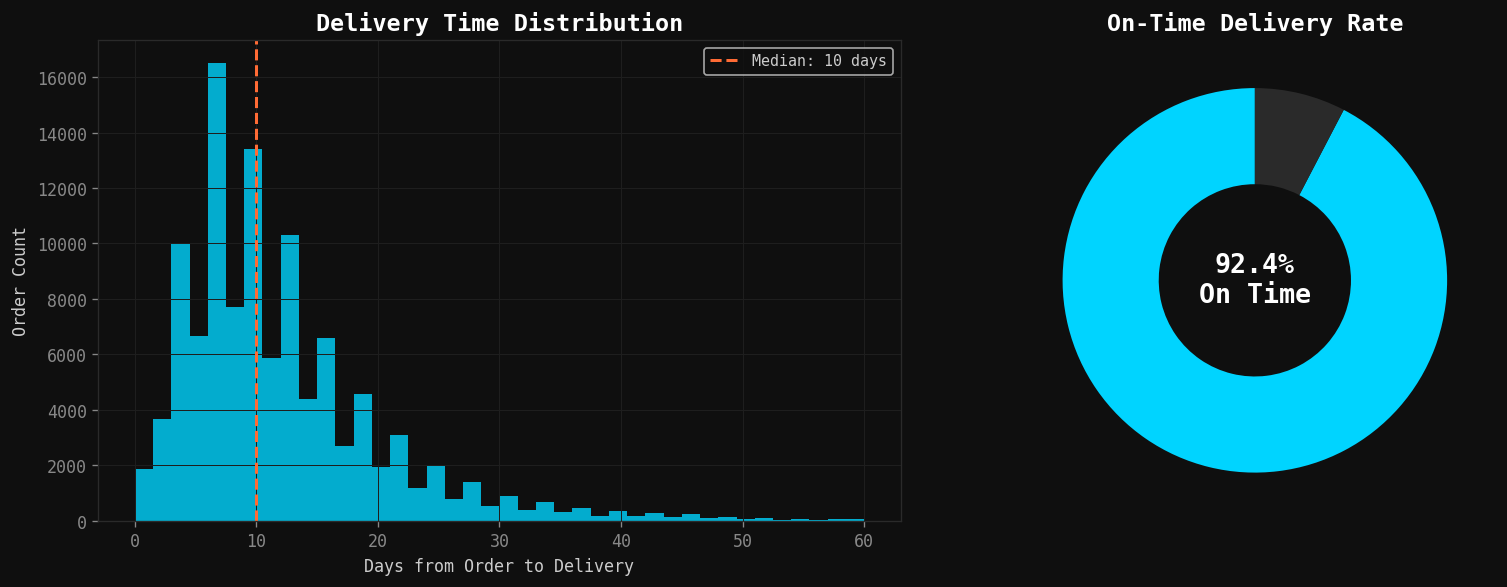

In [16]:
delivery_clean = df.dropna(subset=['delivery_days'])
delivery_clean = delivery_clean[delivery_clean['delivery_days'].between(0, 60)]
on_time_pct    = delivery_clean['delivered_on_time'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delivery_clean['delivery_days'], bins=40,
             color=ACCENT, alpha=0.8, edgecolor='none')
axes[0].axvline(delivery_clean['delivery_days'].median(),
                color=ACCENT2, linewidth=1.8, linestyle='--',
                label=f"Median: {delivery_clean['delivery_days'].median():.0f} days")
axes[0].set_title('Delivery Time Distribution')
axes[0].set_xlabel('Days from Order to Delivery')
axes[0].set_ylabel('Order Count')
axes[0].legend(fontsize=9)

sizes = [on_time_pct, 100 - on_time_pct]
axes[1].pie(sizes, colors=[ACCENT, '#2a2a2a'], startangle=90,
            wedgeprops=dict(width=0.5))
axes[1].text(0, 0, f'{on_time_pct:.1f}%\nOn Time',
             ha='center', va='center', fontsize=16,
             color='white', fontweight='bold')
axes[1].set_title('On-Time Delivery Rate')

plt.tight_layout()
plt.savefig('delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Review Score vs Delivery Time

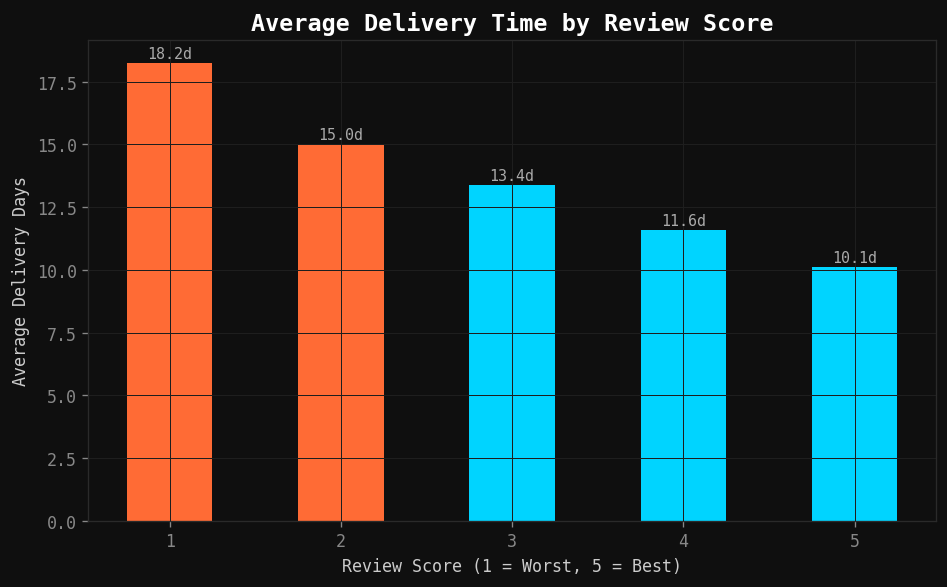

In [17]:
review_delivery = (
    df.merge(reviews[['order_id','review_score']], on='order_id', how='left')
    .dropna(subset=['review_score','delivery_days'])
)
review_delivery = review_delivery[review_delivery['delivery_days'].between(0, 60)]
avg_by_score    = review_delivery.groupby('review_score')['delivery_days'].mean()

bar_colors = [ACCENT2 if s <= 2 else ACCENT for s in avg_by_score.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(avg_by_score.index, avg_by_score.values, color=bar_colors, width=0.5)

for score, val in zip(avg_by_score.index, avg_by_score.values):
    ax.text(score, val + 0.2, f'{val:.1f}d',
            ha='center', fontsize=9, color='#aaaaaa')

ax.set_title('Average Delivery Time by Review Score')
ax.set_xlabel('Review Score (1 = Worst, 5 = Best)')
ax.set_ylabel('Average Delivery Days')
ax.set_xticks([1,2,3,4,5])
plt.tight_layout()
plt.savefig('review_vs_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Summary of Key Findings

| # | Finding |
|---|---|
| 1 | Revenue peaked in November 2017 (Black Friday effect), followed by consistent growth into 2018 |
| 2 | Health & Beauty is the highest revenue-generating category, followed by Watches & Gifts |
| 3 | Peak ordering hours are between 10:00-16:00 on weekdays |
| 4 | Median delivery time is approximately 12 days; over 93% of orders are delivered on time |
| 5 | Clear negative correlation between delivery time and review score |

---
**Author:** Andre Musari  
[GitHub](https://github.com/andremusari276-coder) | [LinkedIn](https://linkedin.com/in/andr0031)